In [40]:
import pickle

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from train_nn import MLP, Config
from flax.training.train_state import TrainState
import optax



In [41]:
with open("./networks/ETL_snr_nn.pkl", "rb") as f:
    network_dict = pickle.load(f)
    params = network_dict["params"]
    config = network_dict["config"]
    net = MLP(config.layer_sizes)
    
    # Create train state without optimizer
    state = TrainState.create(apply_fn=net.apply, params=params, tx=optax.adam(config.learning_rate))

with open("./networks/ETL_snr_nn_scalers.pkl", "rb") as f:
    scaler_dict = pickle.load(f)
    Xscaler = scaler_dict["Xscaler"]
    yscaler = scaler_dict["yscaler"]

def call_network(X):

    X = Xscaler.transform(X)
    y = state.apply_fn({"params": state.params}, X, train=False)
    return yscaler.inverse_transform(y)

In [48]:
df = pd.read_csv("./training_data/train_ETL_3.dat", sep=" ")
X = df.loc[:, ["mass_1_source", "mass_2_source", "theta_jn", "alt", "az", "psi"]].to_numpy()
X[:, 0] = df["mass_1_source"] + df["mass_2_source"]
X[:, 1] = df["mass_2_source"] / df["mass_1_source"]
y_test = df.loc[:, "snr"].to_numpy().reshape(-1, 1)

In [49]:
y_pred = jax.vmap(call_network)(X)


In [50]:
err = ( np.abs(y_test - 10**y_pred) / y_test ) 

(array([9.3097e+04, 5.9940e+03, 6.0000e+02, 2.0000e+02, 5.8000e+01,
        2.9000e+01, 1.0000e+01, 5.0000e+00, 4.0000e+00, 3.0000e+00]),
 array([1.84714703e-07, 6.41038332e-01, 1.28207648e+00, 1.92311463e+00,
        2.56415277e+00, 3.20519092e+00, 3.84622907e+00, 4.48726722e+00,
        5.12830536e+00, 5.76934351e+00, 6.41038166e+00]),
 <BarContainer object of 10 artists>)

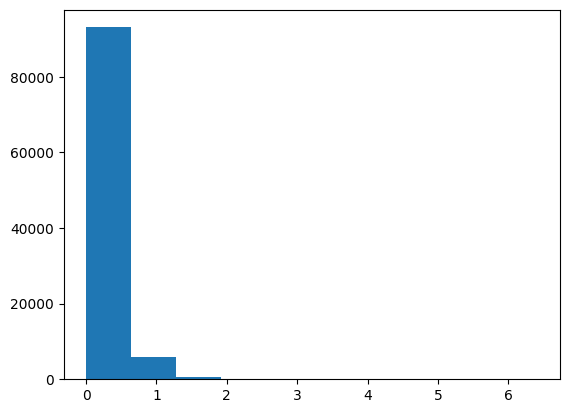

In [51]:
plt.hist(err)

In [52]:
np.mean((np.log10(y_test) - y_pred)**2)

Array(0.02018834, dtype=float32)

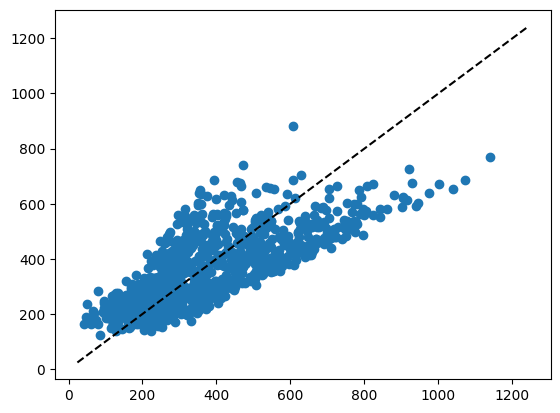

In [55]:
plt.scatter(y_test[::100], 10**y_pred[::100])

plt.plot(np.linspace(y_test.min(), y_test.max(), 2), np.linspace(y_test.min(), y_test.max(), 2), color="black", linestyle='dashed')

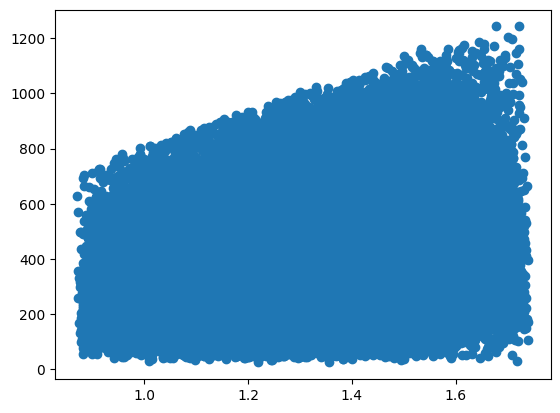

In [27]:
plt.scatter((df["mass_1_source"] * df["mass_2_source"])**(0.6) / (df["mass_1_source"] + df["mass_2_source"])**0.2, df["snr"])

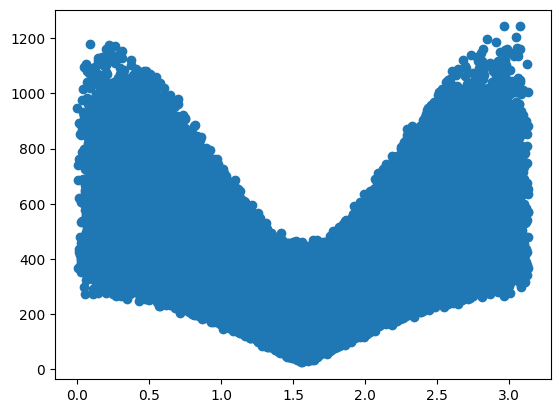

In [28]:
plt.scatter((df["theta_jn"]), df["snr"])

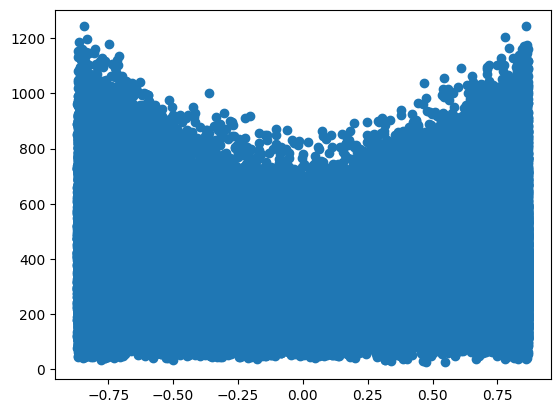

In [31]:
plt.scatter((df["alt"]), df["snr"])

In [28]:
np.sum(df["snr"]<100) / df.shape[0]

np.float64(0.01471)